In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import roc_curve, auc, precision_recall_curve
from sklearn.metrics import roc_auc_score, average_precision_score

In [5]:
df = pd.read_csv('athletes.csv')
df.info()
print("Пропущенные значения до обработки:")
print(df.isnull().sum())


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11538 entries, 0 to 11537
Data columns (total 11 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   id           11538 non-null  int64  
 1   name         11538 non-null  object 
 2   nationality  11538 non-null  object 
 3   sex          11538 non-null  object 
 4   dob          11537 non-null  object 
 5   height       11208 non-null  float64
 6   weight       10879 non-null  float64
 7   sport        11538 non-null  object 
 8   gold         11538 non-null  int64  
 9   silver       11538 non-null  int64  
 10  bronze       11538 non-null  int64  
dtypes: float64(2), int64(4), object(5)
memory usage: 991.7+ KB
Пропущенные значения до обработки:
id               0
name             0
nationality      0
sex              0
dob              1
height         330
weight         659
sport            0
gold             0
silver           0
bronze           0
dtype: int64


In [6]:
# Удаление строк с пропусками в целевой переменной 'sex'
df = df.dropna(subset=['sex'])

In [10]:
# Заполнение пропусков в числовых столбцах медианой
numeric_cols = df.select_dtypes(include=np.number).columns
df[numeric_cols] = df[numeric_cols].fillna(df[numeric_cols].median())
df.isnull().sum()

id             0
name           0
nationality    0
sex            0
dob            1
height         0
weight         0
sport          0
gold           0
silver         0
bronze         0
dtype: int64

In [11]:
# Закодируем категориальные переменные
categorical_cols = df.select_dtypes(include=['object']).columns.drop('sex')
for col in categorical_cols:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col].astype(str))

# Кодирование целевой переменной
le_sex = LabelEncoder()
df['sex'] = le_sex.fit_transform(df['sex'])

In [12]:
# 2. Разделение выборки
X = df.drop('sex', axis=1)
y = df['sex']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Стандартизация данных
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [14]:
# 3. Обучение модели
model = LogisticRegression(max_iter=1000, random_state=42)
model.fit(X_train, y_train)

# Предсказание вероятностей
y_pred_proba = model.predict_proba(X_test)[:, 1]
y_pred_proba


array([0.7377317 , 0.69791836, 0.93569225, ..., 0.48348205, 0.1841249 ,
       0.91430809], shape=(2308,))

In [15]:
# 4. ROC-кривая и ROC-AUC с использованием sklearn
fpr_sklearn, tpr_sklearn, thresholds_sklearn = roc_curve(y_test, y_pred_proba)
roc_auc_sklearn = roc_auc_score(y_test, y_pred_proba)

In [16]:
# 5. Ручной расчет TPR и FPR
def manual_roc_curve(y_true, y_scores):
    thresholds = np.linspace(0, 1, 100)
    tpr = []
    fpr = []
    
    for thresh in thresholds:
        y_pred = (y_scores >= thresh).astype(int)
        
        tp = np.sum((y_pred == 1) & (y_true == 1))
        fn = np.sum((y_pred == 0) & (y_true == 1))
        fp = np.sum((y_pred == 1) & (y_true == 0))
        tn = np.sum((y_pred == 0) & (y_true == 0))
        
        tpr.append(tp / (tp + fn) if (tp + fn) > 0 else 0)
        fpr.append(fp / (fp + tn) if (fp + tn) > 0 else 0)
    
    return np.array(fpr), np.array(tpr), thresholds

fpr_manual, tpr_manual, thresholds_manual = manual_roc_curve(y_test, y_pred_proba)

In [17]:
# Ручной расчет ROC-AUC (метод трапеций)
def manual_roc_auc(fpr, tpr):
    area = 0
    for i in range(1, len(fpr)):
        dx = fpr[i] - fpr[i-1]
        dy = tpr[i] + tpr[i-1]
        area += dx * dy / 2
    return area

roc_auc_manual = manual_roc_auc(fpr_manual, tpr_manual)

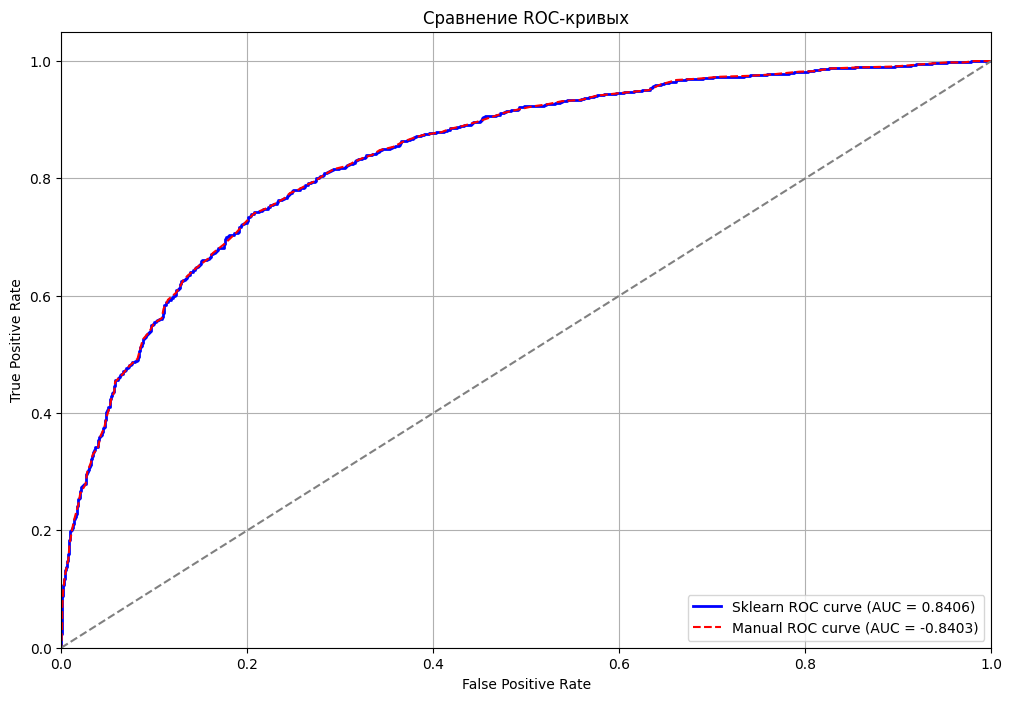

In [18]:
# 6. Сравнение ROC-кривых
plt.figure(figsize=(12, 8))
plt.plot(fpr_sklearn, tpr_sklearn, color='blue', lw=2, 
         label=f'Sklearn ROC curve (AUC = {roc_auc_sklearn:.4f})')
plt.plot(fpr_manual, tpr_manual, color='red', linestyle='--', 
         label=f'Manual ROC curve (AUC = {roc_auc_manual:.4f})')
plt.plot([0, 1], [0, 1], color='gray', linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Сравнение ROC-кривых')
plt.legend(loc="lower right")
plt.grid(True)
plt.show()

In [19]:
# 7. График Precision-Recall (ручной расчет)
def manual_precision_recall(y_true, y_scores):
    thresholds = np.linspace(0, 1, 100)
    precisions = []
    recalls = []
    
    for thresh in thresholds:
        y_pred = (y_scores >= thresh).astype(int)
        
        tp = np.sum((y_pred == 1) & (y_true == 1))
        fp = np.sum((y_pred == 1) & (y_true == 0))
        fn = np.sum((y_pred == 0) & (y_true == 1))
        
        precision = tp / (tp + fp) if (tp + fp) > 0 else 1
        recall = tp / (tp + fn) if (tp + fn) > 0 else 0
        
        precisions.append(precision)
        recalls.append(recall)
    
    return np.array(precisions), np.array(recalls), thresholds

precision_manual, recall_manual, _ = manual_precision_recall(y_test, y_pred_proba)
ap_manual = average_precision_score(y_test, y_pred_proba)


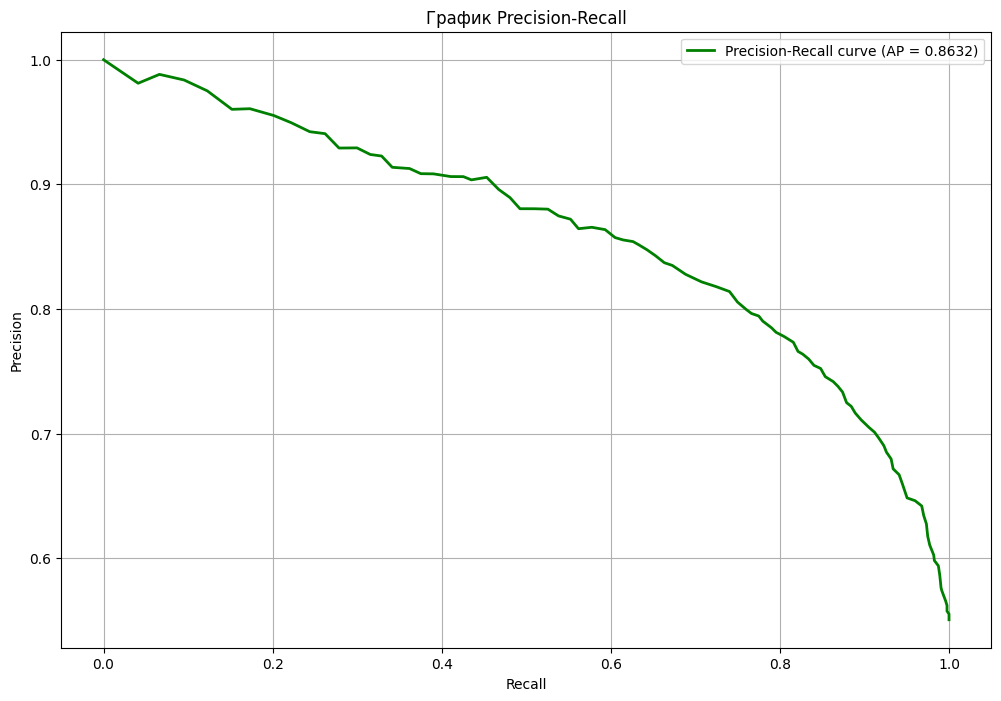

In [20]:
plt.figure(figsize=(12, 8))
plt.plot(recall_manual, precision_manual, color='green', lw=2, 
         label=f'Precision-Recall curve (AP = {ap_manual:.4f})')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('График Precision-Recall')
plt.legend(loc="upper right")
plt.grid(True)
plt.show()

In [ ]:
# 8. Ответы на вопросы
print("\nОтветы на теоретические вопросы:")
print("a) Качество модели определяется по:")
print("   - ROC-AUC: ближе к 1 = лучше модель")
print("   - Форме ROC-кривой: чем больше выпукла влево-вверх, тем лучше")
print("   - Precision-Recall: высокие значения при балансе классов")
print(f"   Модель: ROC-AUC = {roc_auc_sklearn:.4f}, что указывает на хорошее качество")
print("\nb) ROC-кривая не может быть ниже диагонали:")
print("   При инверсии классов кривая зеркально отразится относительно диагонали")


Ответы на теоретические вопросы:
a) Качество модели определяется по:
   - ROC-AUC: ближе к 1 = лучше модель
   - Форме ROC-кривой: чем больше выпукла влево-вверх, тем лучше
   - Precision-Recall: высокие значения при балансе классов
   Наша модель: ROC-AUC = 0.8406, что указывает на хорошее качество

b) ROC-кривая не может быть ниже диагонали:
   При инверсии классов кривая зеркально отразится относительно диагонали
